## 1. Imports

In [15]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.preprocessing import StandardScaler
import joblib

## 2. Data Split and Normalization

In [5]:
df = pd.read_csv('data/clean_dataset.csv')

In [6]:
x = df.drop(columns = ['stress_level'])
y = df['stress_level']

x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size = 0.3, random_state = 42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size = 0.5, random_state = 42
)

In [13]:
FEATURE_COLS = x_train.columns.tolist()
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

['models/feature_cols.pkl']

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_val = scaler.transform(x_val)
X_test = scaler.transform(x_test)

In [10]:
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

## 3. Baseline model

In [23]:
model_baseline = Sequential([
    Dense(64, activation = 'relu', input_shape = (x_train.shape[1],)),
    Dense(32, activation = 'relu'),
    Dense(1)
])

c:\Users\andre\stress-prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model_baseline.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [25]:
history = model_baseline.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 100,
    batch_size = 64
)

Epoch 1/100


165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48.6418 - mae: 6.3979 - val_loss: 37.9402 - val_mae: 5.5466
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 25.2756 - mae: 4.3511 - val_loss: 14.4115 - val_mae: 3.2581
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.0161 - mae: 2.7437 - val_loss: 7.7132 - val_mae: 2.4361
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6462 - mae: 2.4243 - val_loss: 7.4045 - val_mae: 2.3673
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.5804 - mae: 2.4027 - val_loss: 7.3969 - val_mae: 2.3613
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5799 - mae: 2.4013 - val_loss: 7.3964 - val_mae: 2.3602
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5812 - mae: 2.4006 - val_loss: 7.3962 - val_mae: 2.3598
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5822 - mae: 2.3994 - val_loss: 7.3973 - val_mae: 2.3618
Epoch 9/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - 

In [21]:
def visualizar_graficas(history):
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    eps = range(1, len(mae) + 1)

    # MAE
    plt.plot(eps, mae, 'r', label='train MAE')
    plt.plot(eps, val_mae, 'b', label='validation MAE')
    plt.title('Train MAE vs. Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()

    plt.figure()

    # Loss (MSE)
    plt.plot(eps, loss, 'r', label='training loss (MSE)')
    plt.plot(eps, val_loss, 'b', label='validation loss (MSE)')
    plt.title('Train Loss vs. Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()

    plt.show()

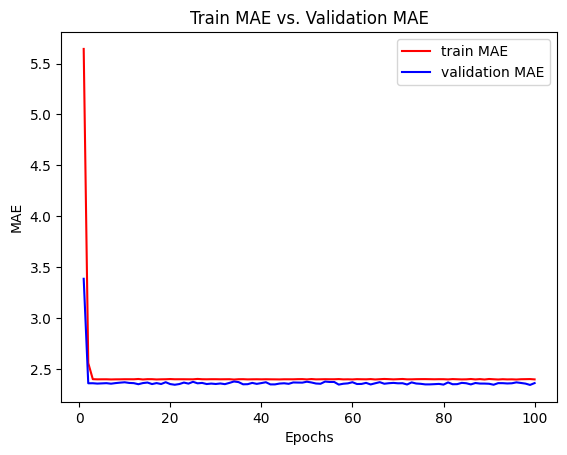

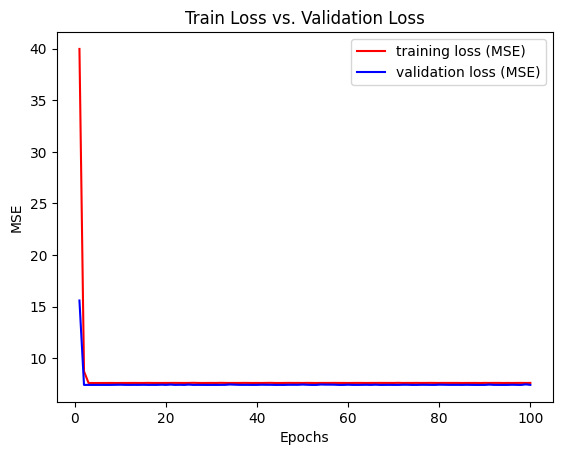

In [26]:
visualizar_graficas(history)

In [ ]:
model_baseline.save('models/model_baseline.keras')

## 4. Refinement

In [49]:
df2 = pd.read_csv('data/engineered_dataset.csv')

x2 = df2.drop(columns = ['stress_level'])
y2 = df2['stress_level']

x_train2, x_temp2, y_train2, y_temp2 = train_test_split(
    x2, y2, test_size = 0.3, random_state = 42
)

x_val2, x_test2, y_val2, y_test2 = train_test_split(
    x_temp2, y_temp2, test_size = 0.5, random_state = 42
)

In [50]:
X_train2 = scaler.fit_transform(x_train2)
X_val2 = scaler.transform(x_val2)
X_test2 = scaler.transform(x_test2)

In [51]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train2.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

c:\Users\andre\stress-prediction\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [53]:
history2 = model.fit(
    X_train2, y_train2,
    validation_data = (X_val2, y_val2),
    epochs = 100,
    batch_size = 32
)

Epoch 1/100


329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 26.6952 - mae: 4.3075 - val_loss: 13.2886 - val_mae: 3.1319
Epoch 2/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.3049 - mae: 2.4729 - val_loss: 11.8308 - val_mae: 2.9643
Epoch 3/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.1056 - mae: 2.4533 - val_loss: 8.5660 - val_mae: 2.5628
Epoch 4/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.9635 - mae: 2.4432 - val_loss: 7.6456 - val_mae: 2.4244
Epoch 5/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.9553 - mae: 2.4416 - val_loss: 8.0075 - val_mae: 2.4831
Epoch 6/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.8644 - mae: 2.4284 - val_loss: 7.4417 - val_mae: 2.3466
Epoch 7/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.9038 - mae: 2.4385 - val_loss: 7.4917 - val_mae: 2.3447
Epoch 8/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.8367 - mae: 2.4267 - val_loss: 7.4243 - val_mae: 2.3483
Epoch 9/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

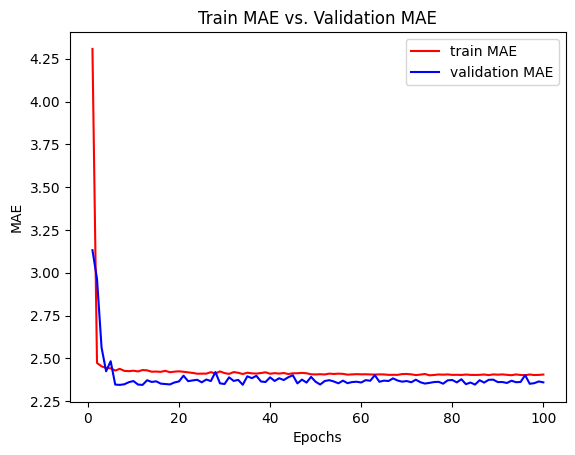

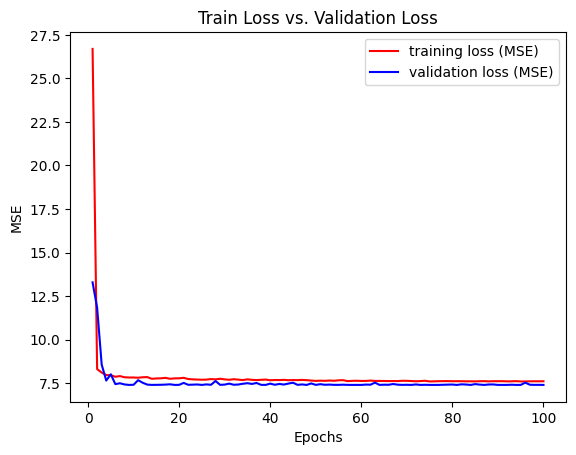

In [54]:
visualizar_graficas(history2)